# TS5 - Estimacion Espectral 2, Ventanas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

Funciones auxiliares:

In [2]:

def plot_psd_señal(xx, fs, N, title="Densidad Espectral de Potencia", type="scatter", xlabel="freq"):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(N, d=1/fs)

    psd = 2 * (1/(fs*N)) * np.abs(xx_fft)**2

    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    if xlabel =="k":
        freqs = np.arange(len(psd))
        xlb = "k"
    else:
        xlb = "Frecuencia (Hz)"

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    if type == "scatter":
        axs[0].scatter(freqs, psd)
    else:
        axs[0].plot(freqs, psd)
    axs[0].set_xlabel(xlb)
    axs[0].set_ylabel('$|X(k)^2|$ [W]')
    axs[0].grid(True)
    axs[0].set_title(title)

    if type == "scatter":
        axs[1].scatter(freqs, 10*np.log10(psd))
    else:
        axs[1].plot(freqs, 10*np.log10(psd))
    axs[1].set_xlabel(xlb)
    axs[1].set_ylabel('$|X(k)^2|$ [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    figure.tight_layout()
    plt.show()

    return psd, freqs

## Experimento de $\hat{a}_1^{\,i}$ para una SNR de 10 dB

Vamos a generar una señal senoidal donde la frecuencia este compuesta sea una variable aleatoria.
$$
x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)
$$

$$
\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}
$$

$$
\Omega_0 = \frac{\pi}{2}
$$

Con las variables aleatorias:

$$
f_r \sim \mathcal{U}(-2,\,2)
$$

$$
n_a \sim \mathcal{N}(0,\,\sigma^2)
$$


Tendremos un vector $N$ de 1000 muestras y una cantidad $R$ de 200 realizaciones.

Primero probaremos un SNR de señal de 10 dB.

Si tenemos una potencia de señal normalizada de 1W (0 dB) tenemos que tener -10 dB de potencia de ruido.

In [3]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)

def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

pot_ruido_db = -10
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))

Ahora formamos una matriz de RxN que contenga los valores de las 1000 muestras de cada realizacion.

In [4]:
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) * np.sin(ang) + na

x10db = x

Podemos ver el tamaño de la matriz resultante para verificar que las multiplicaciones son correctas (por lo menos en las dimensiones):

In [5]:
print(f"Shape de x: {x.shape}")

Shape de x: (200, 1000)


Ahora calculamos la FFT de la matriz, con el $axis=1$ para que se haga en el eje de muestras.

Despues calculamos el modulo (normalizado) de la matriz.

In [6]:
x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

Podemos graficar algunas realizaciones para ver como es la distribucion de potencia:

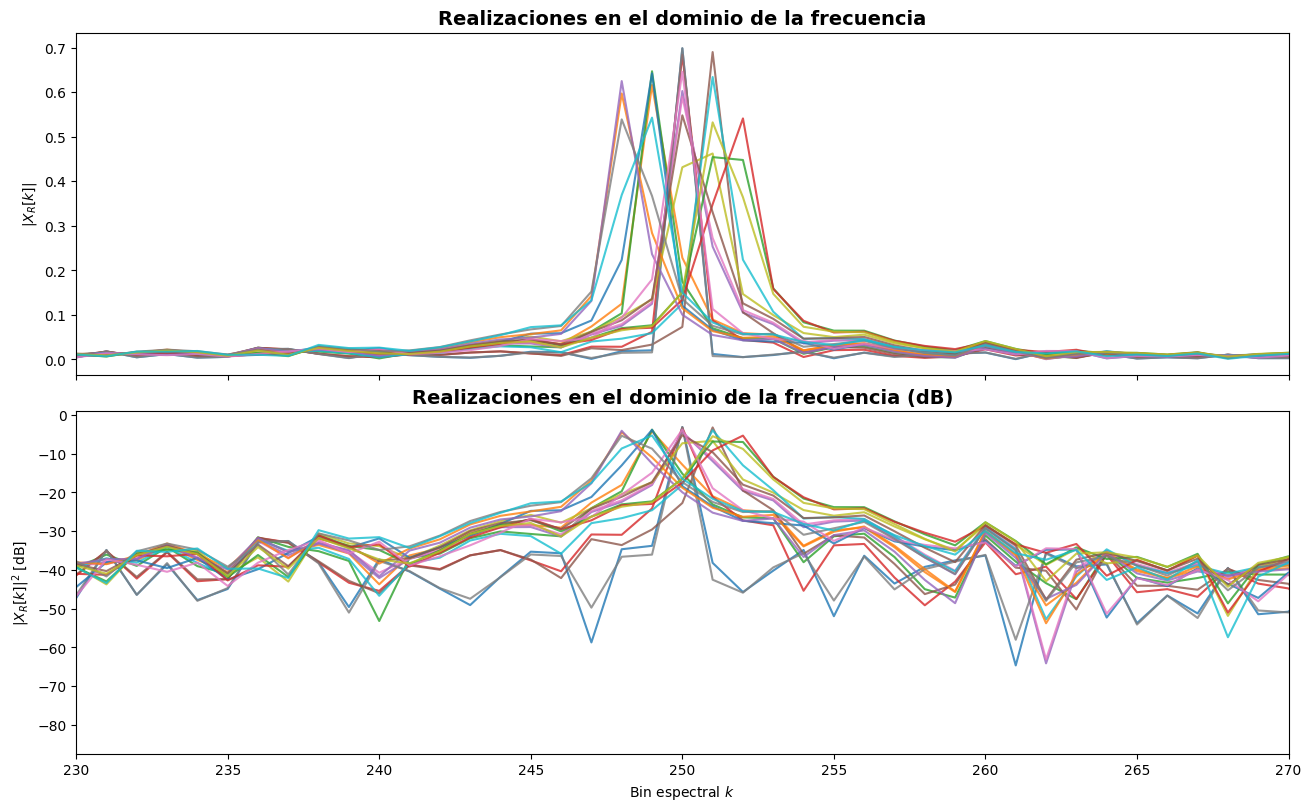

In [7]:
import seaborn as sns

fig, axs = plt.subplots(
    2, 1,
    figsize=(13, 8),
    sharex=True,
    constrained_layout=True
)

# =========================
# Dominio lineal
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=x_fft_abs[i, :],
        ax=axs[0],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[0].set_title(
    "Realizaciones en el dominio de la frecuencia",
    fontsize=14,
    weight='bold'
)

axs[0].set_ylabel(r"$|X_R[k]|$")

axs[0].set_xlim(N//4 - 20, N//4 + 20)

# =========================
# Dominio en dB
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=20 * np.log10(x_fft_abs[i, :] + 1e-12),
        ax=axs[1],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[1].set_title(
    "Realizaciones en el dominio de la frecuencia (dB)",
    fontsize=14,
    weight='bold'
)

axs[1].set_xlabel(r"Bin espectral $k$")
axs[1].set_ylabel(r"$|X_R[k]|^2$ [dB]")

axs[1].set_xlim(N//4 - 20, N//4 + 20)

plt.show()

Definimos el primer estimador, un estimador de energia:

$$
\hat{a}_1^{\,i} = \left| X_w^{\,i}(\Omega_0) \right| = \left| \mathcal{F}\{ x(n)\cdot w_i(n) \} \right|
$$

Siendo $w_i(n)$ la ventana, de la que todavia no hablamos nada. Todavia estamos usando la ventana implicita, que segun vimos en la TS4, genera el kernel de Dirichlet en frecuencia.

Este estimador intenta estimar, valga la redundancia, la energia de la señal obteniendo el valor del bin de $\Omega_0$. No es un buen estimador porque como ya vimos y graficamos, la potencia de la señal está en centrada en distintas frecuencias segun la realizacion gracias a la variable aleatoria que conforma $\Omega_1$ 

Vamos a graficar el histograma de 3 estimadores, uno que toma la energia de $\Omega_0$ como ya dijimos, pero despues otros dos que toman la energia en $\Omega_0 - 1$ y $\Omega_0 + 1$.

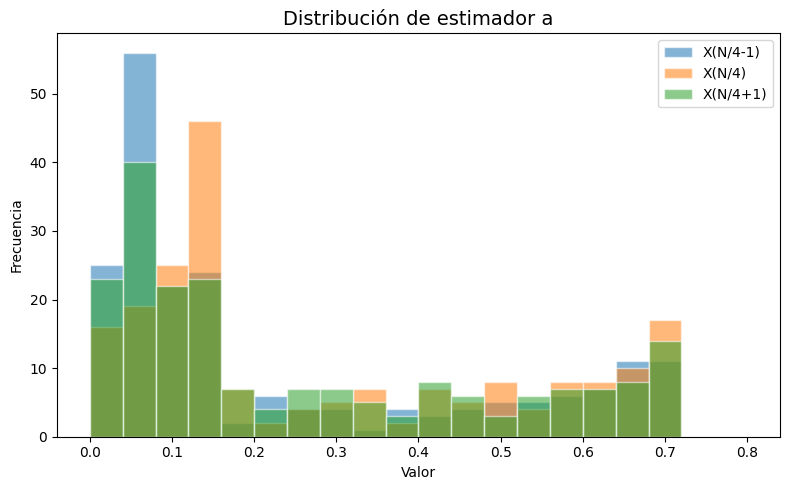

Media del estimador: 0.285
Varianza del estimador: 0.054
Sesgo del estimador: -0.422


In [8]:
estimador_a_1 = (x_fft_abs[:,int(N/4-1)])
estimador_a = (x_fft_abs[:,int(N/4)])
estimador_a1 = (x_fft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="X(N/4-1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a, label="X(N/4)",bins = 20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a1, label="X(N/4+1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()

sesgo_a = np.mean(estimador_a) - np.sqrt(2)/2

print(f"Media del estimador: {np.mean(estimador_a):.3f}")
print(f"Varianza del estimador: {np.var(estimador_a):.3f}")
print(f"Sesgo del estimador: {sesgo_a:.3f}")

Vemos que la distribucion de los 3 estimadores son similares. Volvemos a tomar el estimador que mencionamos al principio ($X(\Omega_0)$) y le vamos a corregir el sesgo

Media del estimador: 0.707
Varianza del estimador: 0.054
Sesgo del estimador: 0.000


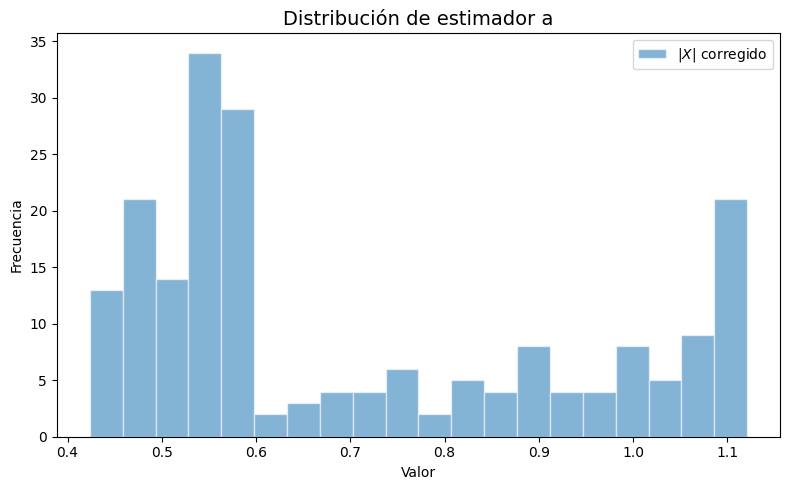

In [9]:
estimador_a_corregido = estimador_a - sesgo_a

print(f"Media del estimador: {np.mean(estimador_a_corregido):.3f}")
print(f"Varianza del estimador: {np.var(estimador_a_corregido):.3f}")
print(f"Sesgo del estimador: {np.mean(estimador_a_corregido) - np.sqrt(2)/2:.3f}")

plt.figure(figsize=(8, 5))
plt.hist(estimador_a_corregido, label="$|X|$ corregido", bins=20, edgecolor='white', alpha=0.55)
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


Creamos una funcion para calcular el estimador y aplicar distintas ventanas de muestreo:

In [10]:
def calcular_estimador_a(x, N, ventana = None, eliminar_sesgo = True, correccion = np.sqrt(2)/2):
    if ventana != None:
        x_ventaneado = x * ventana(N)
    else:
        x_ventaneado = x

    x_fft = np.fft.fft(x_ventaneado, axis=1)
    x_fft_abs = np.abs(x_fft)/N

    estimador = x_fft_abs[:,int(N/4)]

    if eliminar_sesgo:
        sesgo = np.mean(estimador) - correccion
        estimador = estimador - sesgo

    return estimador

Vamos a usar las ventanas Hann, Blackmanharris y Flattop ademas de la rectangular.

### Ventana Hann

$$
w[n] =
\begin{cases}
0.5 \left(1 - \cos\left(\dfrac{2\pi n}{N-1}\right)\right), & 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

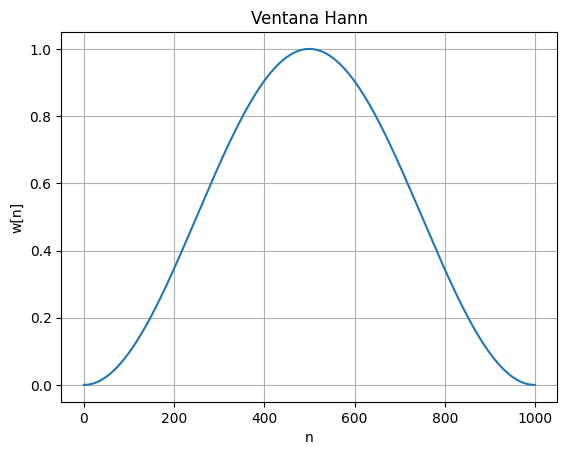

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import hann

w = hann(N)

plt.plot(w)
plt.title("Ventana Hann")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

### Ventana Blackman-Harris

$$
w[n] =
\begin{cases}
a_0
- a_1 \cos\left(\dfrac{2\pi n}{N-1}\right)
+ a_2 \cos\left(\dfrac{4\pi n}{N-1}\right)
- a_3 \cos\left(\dfrac{6\pi n}{N-1}\right),
& 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

$$
a_0 = 0.35875,\qquad
a_1 = 0.48829,\qquad
a_2 = 0.14128,\qquad
a_3 = 0.01168
$$

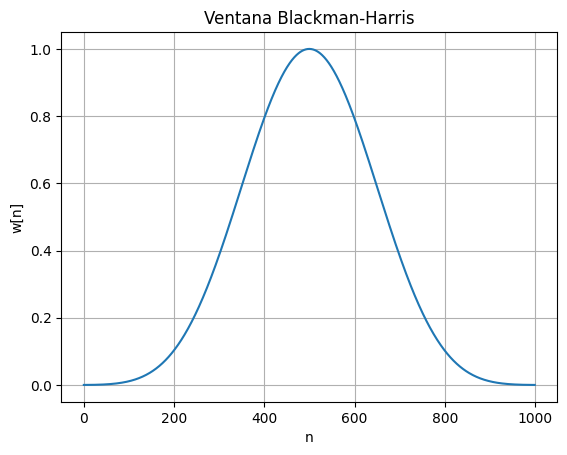

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import blackmanharris

w = blackmanharris(N)

plt.plot(w)
plt.title("Ventana Blackman-Harris")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

### Ventana Flattop

$$
w[n] =
\begin{cases}
a_0
- a_1 \cos\left(\dfrac{2\pi n}{N-1}\right)
+ a_2 \cos\left(\dfrac{4\pi n}{N-1}\right)
- a_3 \cos\left(\dfrac{6\pi n}{N-1}\right)
+ a_4 \cos\left(\dfrac{8\pi n}{N-1}\right),
& 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

$$
a_0 = 1,\qquad
a_1 = 1.93,\qquad
a_2 = 1.29,\qquad
a_3 = 0.388,\qquad
a_4 = 0.028
$$

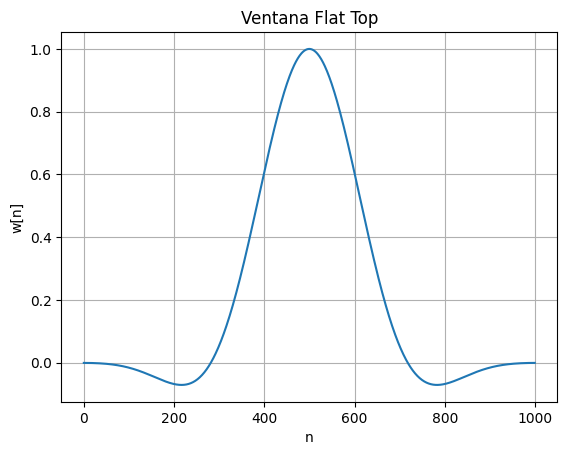

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop

w = flattop(N)

plt.plot(w)
plt.title("Ventana Flat Top")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

Ahora podemos ver la distribucion del estimador $\hat{a}_1^{\,i}$ para las distintas ventanas, y compararlas entre si:

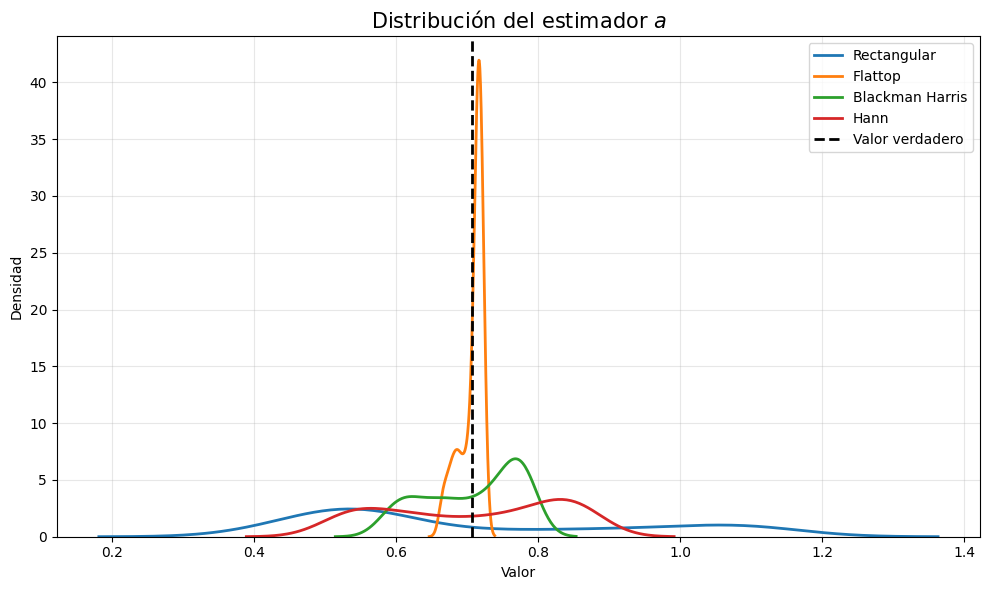

In [14]:
estimador_a_ft = calcular_estimador_a(x10db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x10db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x10db, N, hann)

import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_a_corregido,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_a_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_a_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_a_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $a$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Tambien podemos hacer comparar los estimadores usando violinplots:

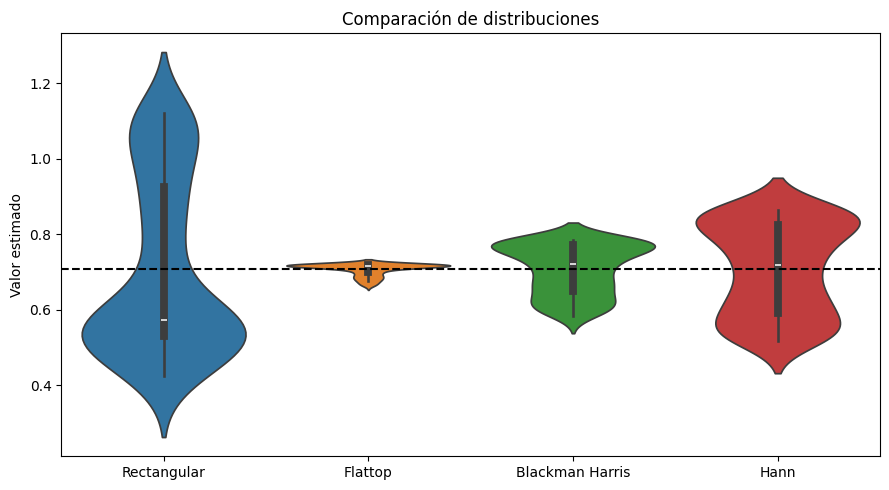

In [15]:
datos = [
    estimador_a_corregido,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones')

plt.tight_layout()
plt.show()

Se ve con gran claridad que para este estimador la ventana de Flattop se destaca muchísimo por sobre las demás. Además de tener una varianza mucho menor, la mediana de la distribución es muy similar al valor esperado del estimador. Podemos comparar los datos:

In [16]:
datos = [
    estimador_a_corregido,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular                0.7071       0.0540       0.5734
Flattop                    0.7071       0.0003       0.7149
Blackman Harris            0.7071       0.0043       0.7217
Hann                       0.7071       0.0148       0.7180


Por supuesto la media en cada ventana es la misma, ya que la estamos corrigiendo cuando corregimos el sesgo.

Se puede concluir que para este estimador conviene mucho usar una ventana Flattop.

## Experimento de $\hat{a}_1^{\,i}$ para una SNR de 3 dB

Generamos nuestra nueva señal:

In [17]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)
pot_ruido_db = -3
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) * np.sin(ang) + na

x3db = x

x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

Podemos graficar las realizaciones:

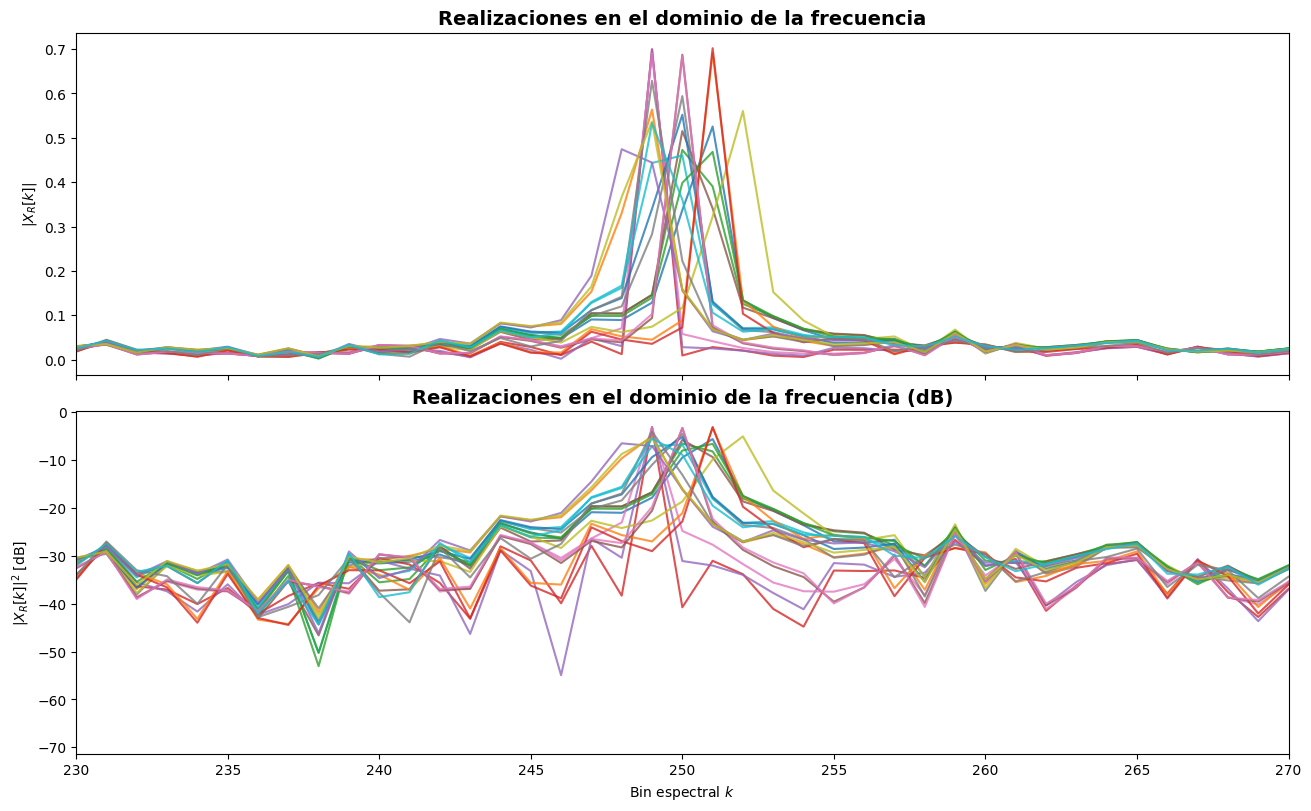

In [18]:
import seaborn as sns

fig, axs = plt.subplots(
    2, 1,
    figsize=(13, 8),
    sharex=True,
    constrained_layout=True
)

# =========================
# Dominio lineal
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=x_fft_abs[i, :],
        ax=axs[0],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[0].set_title(
    "Realizaciones en el dominio de la frecuencia",
    fontsize=14,
    weight='bold'
)

axs[0].set_ylabel(r"$|X_R[k]|$")

axs[0].set_xlim(N//4 - 20, N//4 + 20)

# =========================
# Dominio en dB
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=20 * np.log10(x_fft_abs[i, :] + 1e-12),
        ax=axs[1],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[1].set_title(
    "Realizaciones en el dominio de la frecuencia (dB)",
    fontsize=14,
    weight='bold'
)

axs[1].set_xlabel(r"Bin espectral $k$")
axs[1].set_ylabel(r"$|X_R[k]|^2$ [dB]")

axs[1].set_xlim(N//4 - 20, N//4 + 20)

plt.show()

Generamos los nuevos estimadores:

In [19]:
estimador_a_rectangular = calcular_estimador_a(x3db, N, None)
estimador_a_ft = calcular_estimador_a(x3db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x3db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x3db, N, hann)

Graficamos las distribuciones:

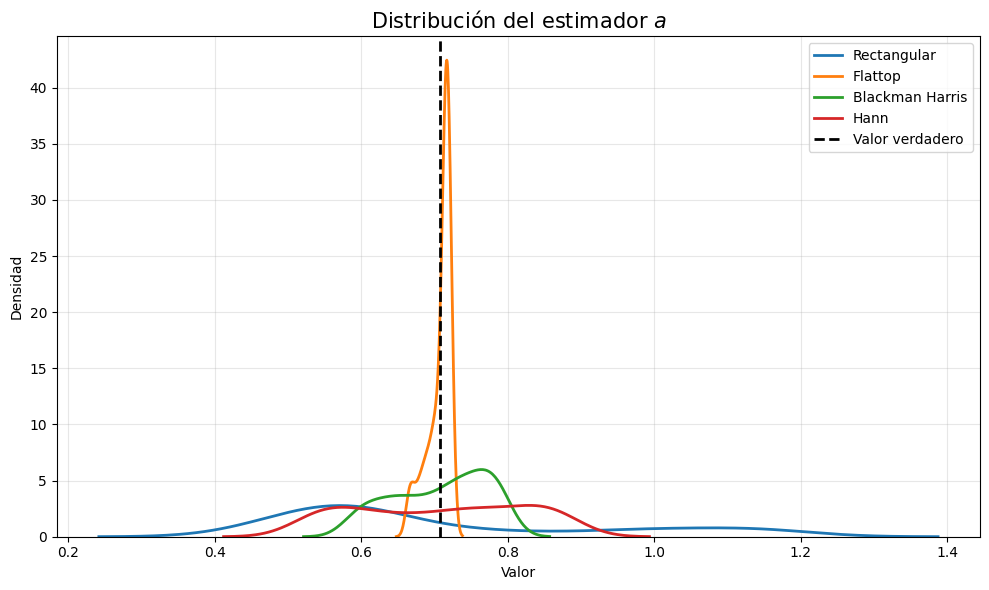

In [20]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_a_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_a_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_a_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_a_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $a$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Generamos los violinplots:

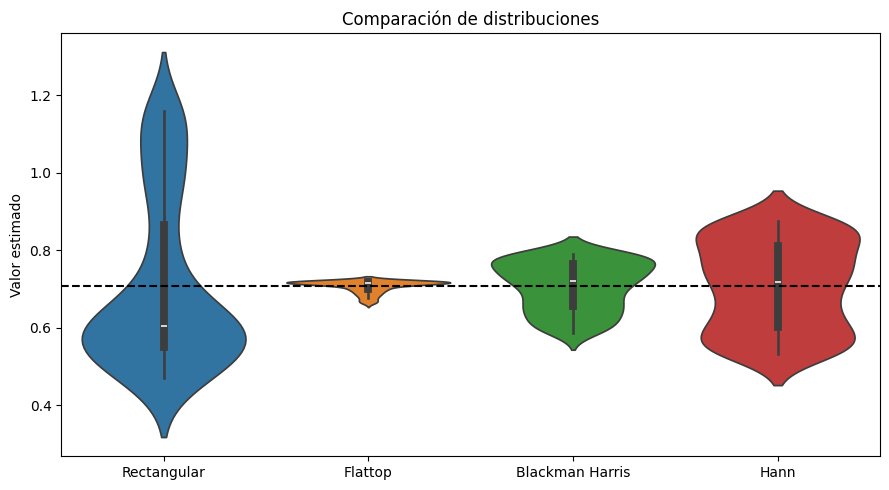

In [21]:
datos = [
    estimador_a_rectangular,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones')

plt.tight_layout()
plt.show()

Generamos la tabla de comparacion:

In [22]:
datos = [
    estimador_a_rectangular,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular                0.7071       0.0478       0.6054
Flattop                    0.7071       0.0002       0.7153
Blackman Harris            0.7071       0.0040       0.7193
Hann                       0.7071       0.0131       0.7167


Empeorar la SNR de la señal **no empeoró** la varianza de los estimadores.

## Experimento de estimacion frecuencial $\hat{\Omega}_1^i$ con SNR de 10dB

$$
\hat{\Omega}_1^i = \arg \max_{\Omega} \left\{ \left| X_w^i(\Omega) \right| \right\}
$$

Se generara un estimador de frecuencia. Se buscara el bin frecuencial mas alto para definirla. Volveremos a usar las variales $x10db$ y $x3db$ generadas en los experimentos anteriores.

Graficamos una realizacion para ilustrar:

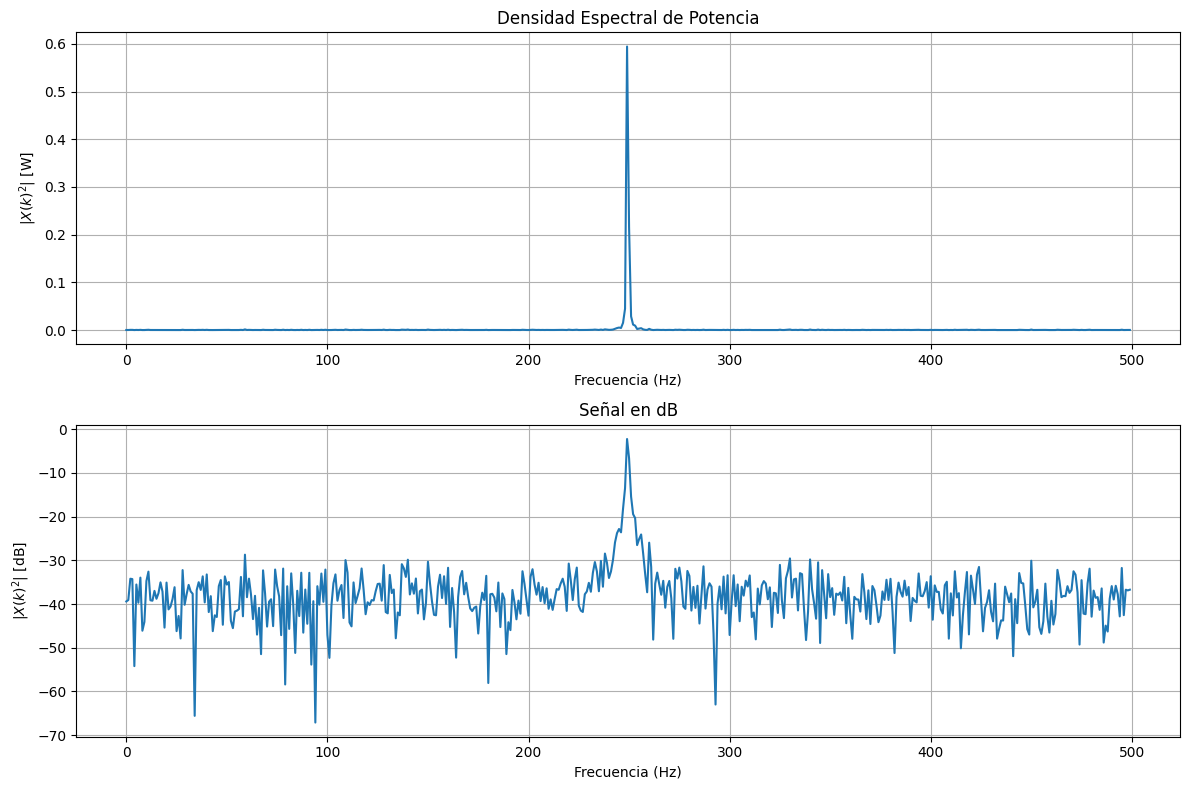

In [23]:
_, _ = plot_psd_señal(x10db[-1,:], fs, N, type="line")

Primero limitamos el espectro a la mitad y despues buscamos el indice de mayor magnitud en cada una de las realizaciones.

In [34]:
x_fft = np.fft.fft(x10db, axis=1)[:, 0:N//2]
x_fft_abs = np.abs(x_fft)/N
estimador_omega = np.argmax(x_fft_abs, axis=1) * (np.pi/2)/(N/2)

print(f"Media del estimador: {np.mean(estimador_omega):.3f}")
print(f"Varianza del estimador: {np.var(estimador_omega):.3f}")
print(f"Sesgo del estimador: {np.mean(estimador_omega) - Omega0:.3f}")

Media del estimador: 0.786
Varianza del estimador: 0.000
Sesgo del estimador: -0.785


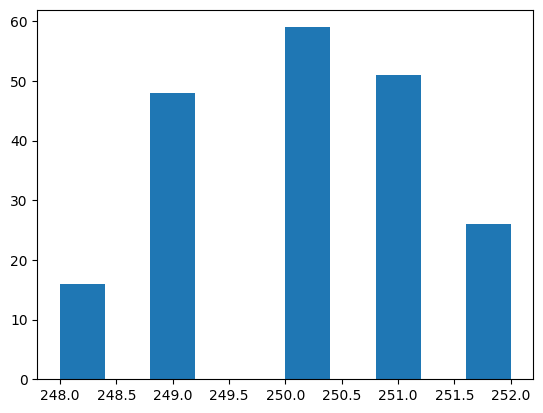

In [30]:
_ = plt.hist(estimador_omega)